<a href="https://colab.research.google.com/github/Olya-Shulga/Univercity/blob/main/neural_networks/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%A0%D0%B0%D0%B7%D0%B2%D1%91%D1%80%D1%82%D1%8B%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%D0%BD%D0%B0_NVIDIA_Triton_Inference_Server.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №11

## Развёртывание модели классификации изображений на NVIDIA Triton Inference Server

**Цель работы:** выполнить контейнеризацию и развёртывание модели классификации изображений с использованием NVIDIA Triton Inference Server, FastAPI, Docker Compose, Prometheus и Grafana.


## 1. Используемая модель

В работе используется модель классификации изображений, обученная в практической работе №10.

Файл модели:

```text
best_model_final.keras
```

Модель экспортируется в формат ONNX и размещается в репозитории моделей Triton:

```text
model_repository/image_classifier/1/model.onnx
```


## 2. Структура проекта

```text
triton_image_classification_project/
├── api/
│   ├── Dockerfile
│   ├── main.py
│   └── requirements.txt
├── model_repository/
│   └── image_classifier/
│       ├── config.pbtxt
│       └── 1/
│           └── model.onnx
├── prometheus/
│   └── prometheus.yml
├── grafana/
│   ├── dashboards/
│   └── provisioning/
├── docker-compose.yml
├── test_client.py
├── load_test.py
├── classes.json
├── model_meta.json
└── README.md
```


## 3. Экспорт модели

Для экспорта Keras-модели в ONNX используется скрипт:

```text
scripts/export_keras_to_onnx.py
```

Команда запуска:

```bash
python scripts/export_keras_to_onnx.py
```

После выполнения формируется ONNX-модель и конфигурационный файл Triton:

```text
model_repository/image_classifier/config.pbtxt
```


In [ ]:
# Команда выполняется в терминале:
# python scripts/export_keras_to_onnx.py


## 4. Запуск сервисов

Проект запускается через Docker Compose:

```bash
docker compose up -d --build
```

В результате запускаются следующие сервисы:

- NVIDIA Triton Inference Server;
- FastAPI-приложение;
- Prometheus;
- Grafana.


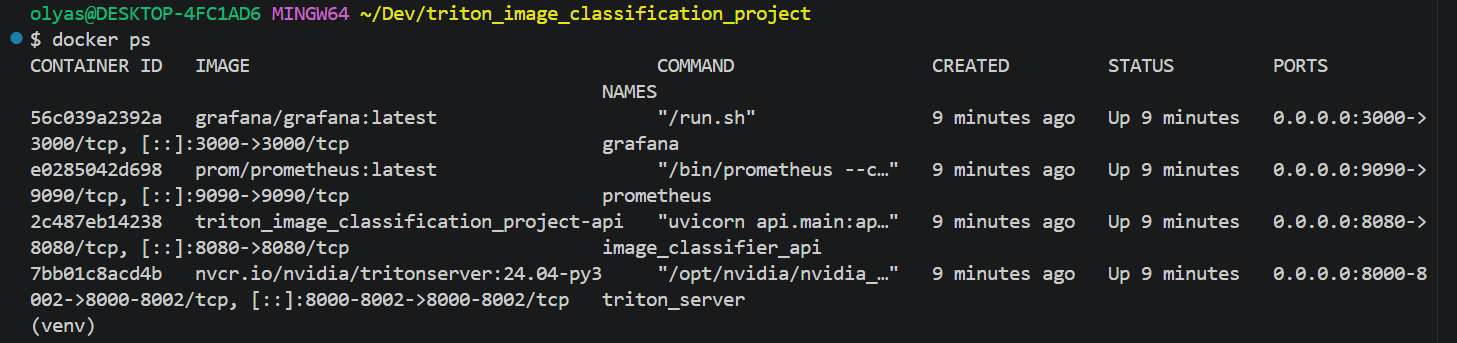

## 5. Проверка доступности сервисов

После запуска доступны следующие адреса:

| Сервис | Адрес |
|---|---|
| Triton health | `http://localhost:8000/v2/health/ready` |
| FastAPI Swagger | `http://localhost:8080/docs` |
| Prometheus | `http://localhost:9090` |
| Grafana | `http://localhost:3000` |


## 6. Проверка инференса

Проверка инференса выполняется через FastAPI Swagger UI:

```text
http://localhost:8080/docs
```

Для endpoint `POST /predict` загружается изображение, после чего API возвращает:

- предсказанный класс;
- уверенность модели;
- вероятности по классам.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Скриншот Swagger UI

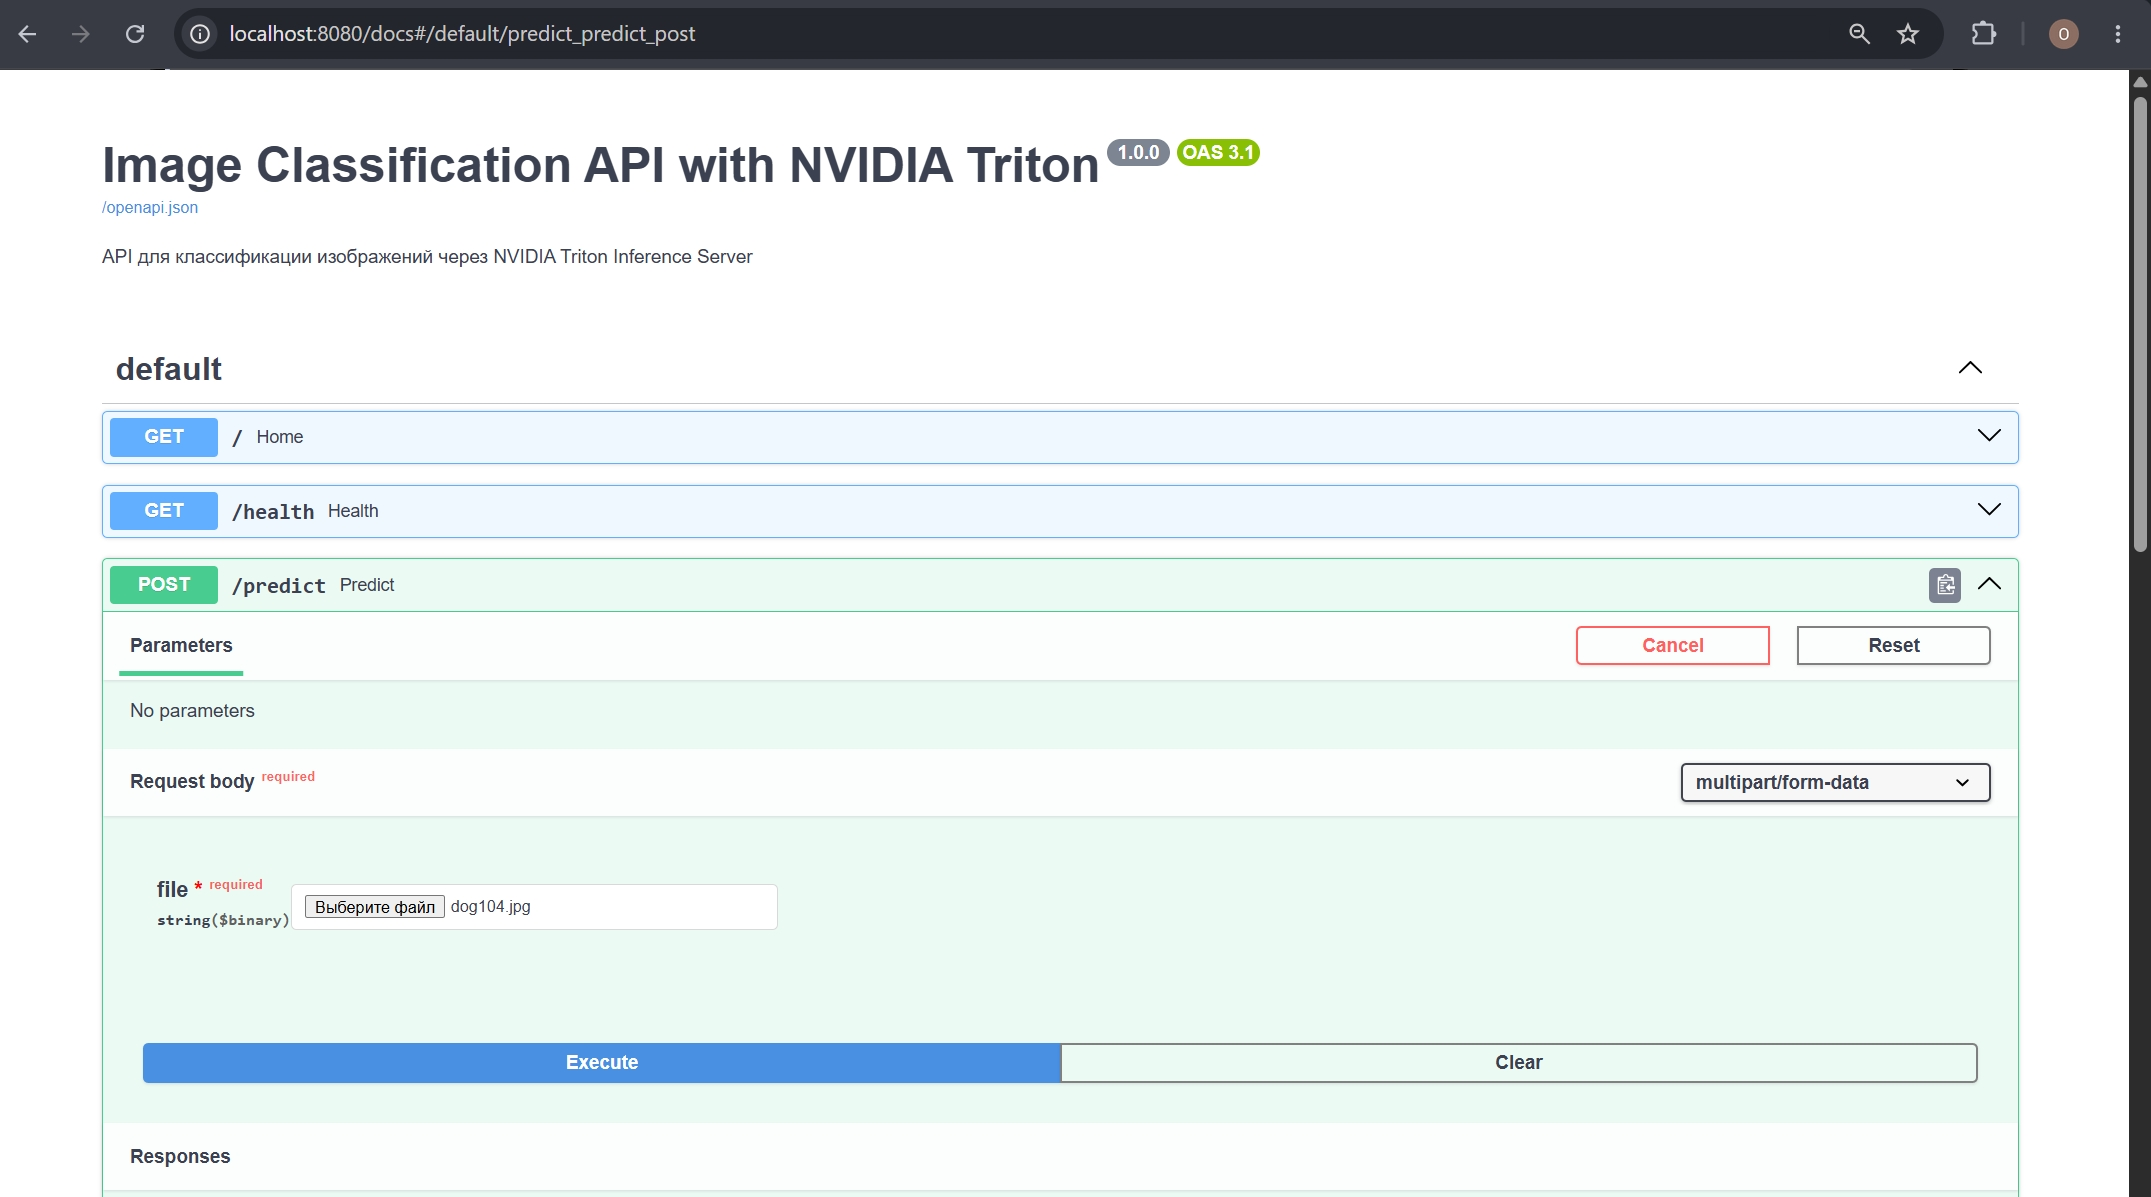


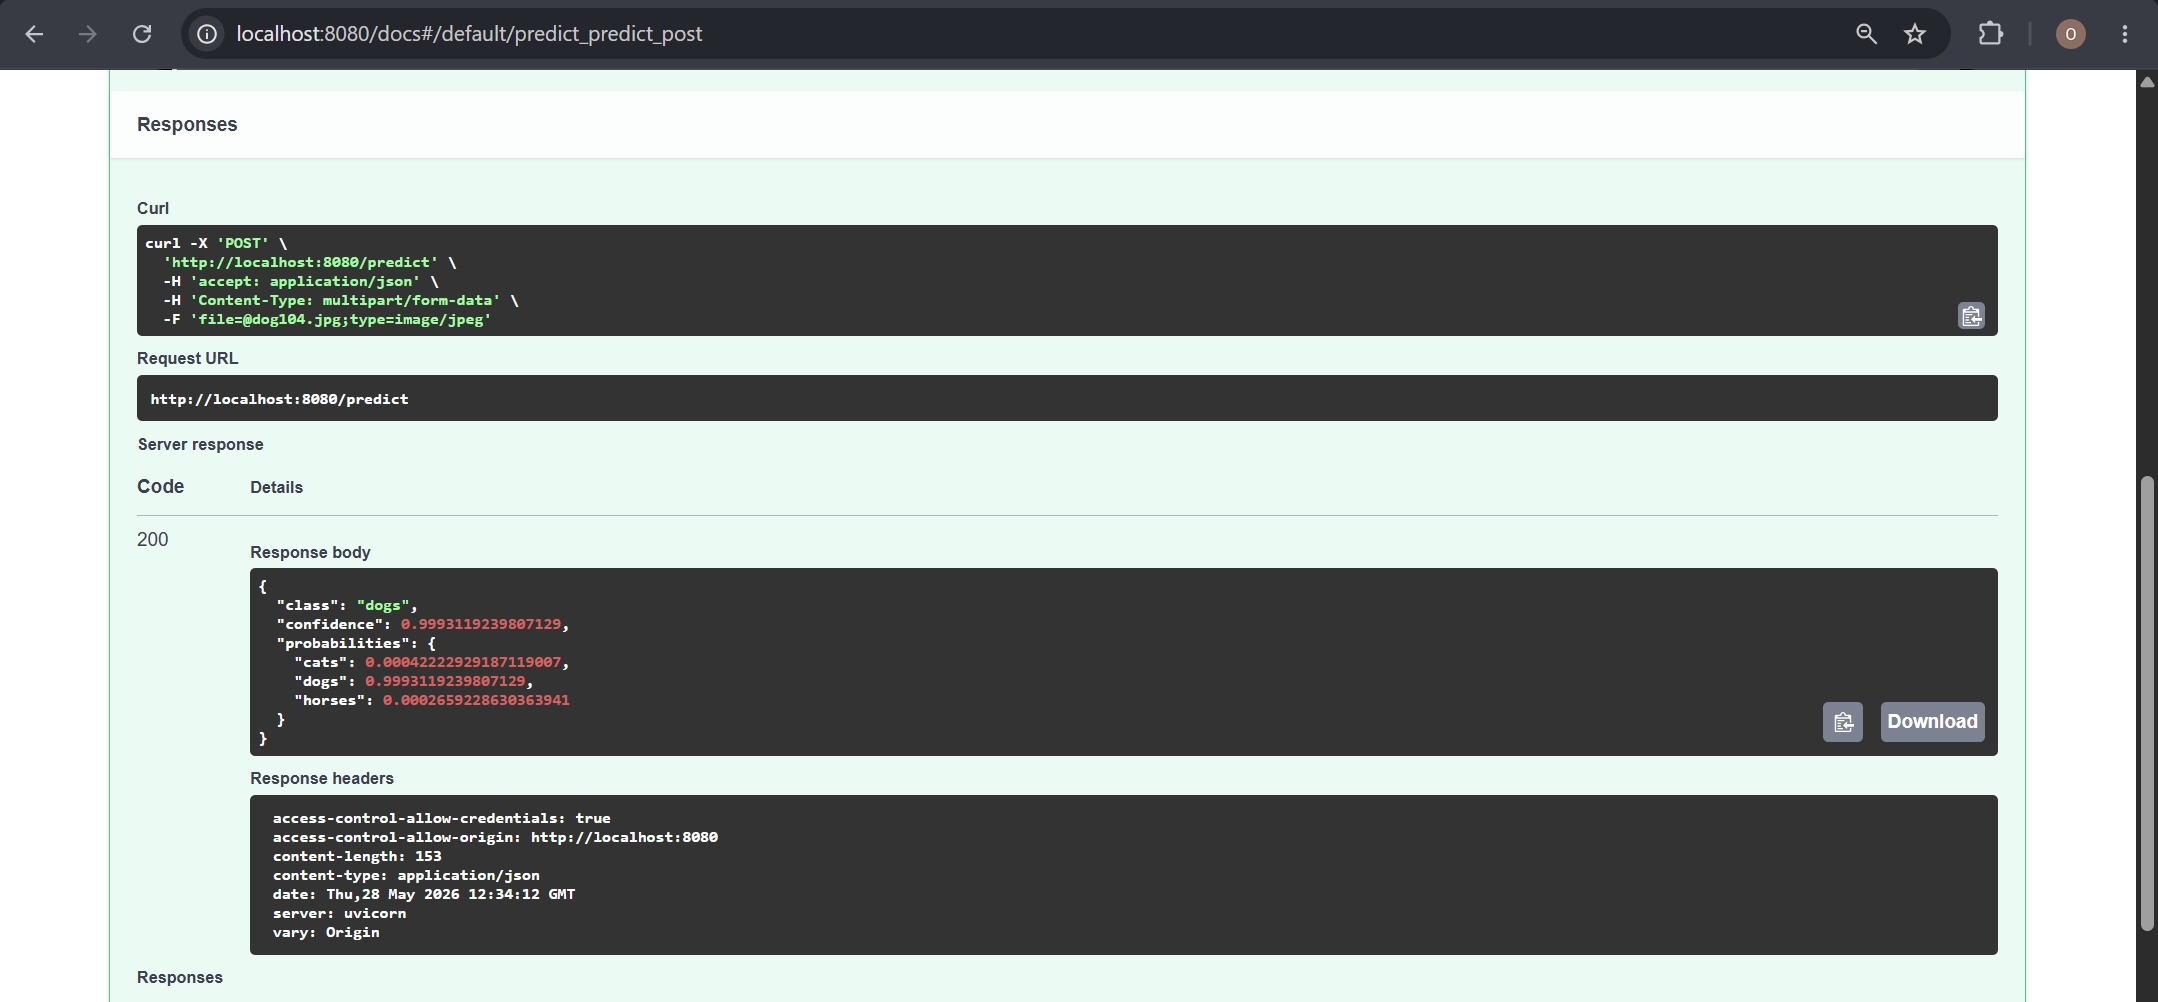


## 7. Мониторинг

Triton предоставляет метрики на порту `8002`. Prometheus собирает эти метрики, а Grafana отображает их в виде графиков.

Prometheus:

```text
http://localhost:9090
```

Grafana:

```text
http://localhost:3000
```

Логин и пароль по умолчанию:

```text
admin / admin
```


### Скриншот Grafana



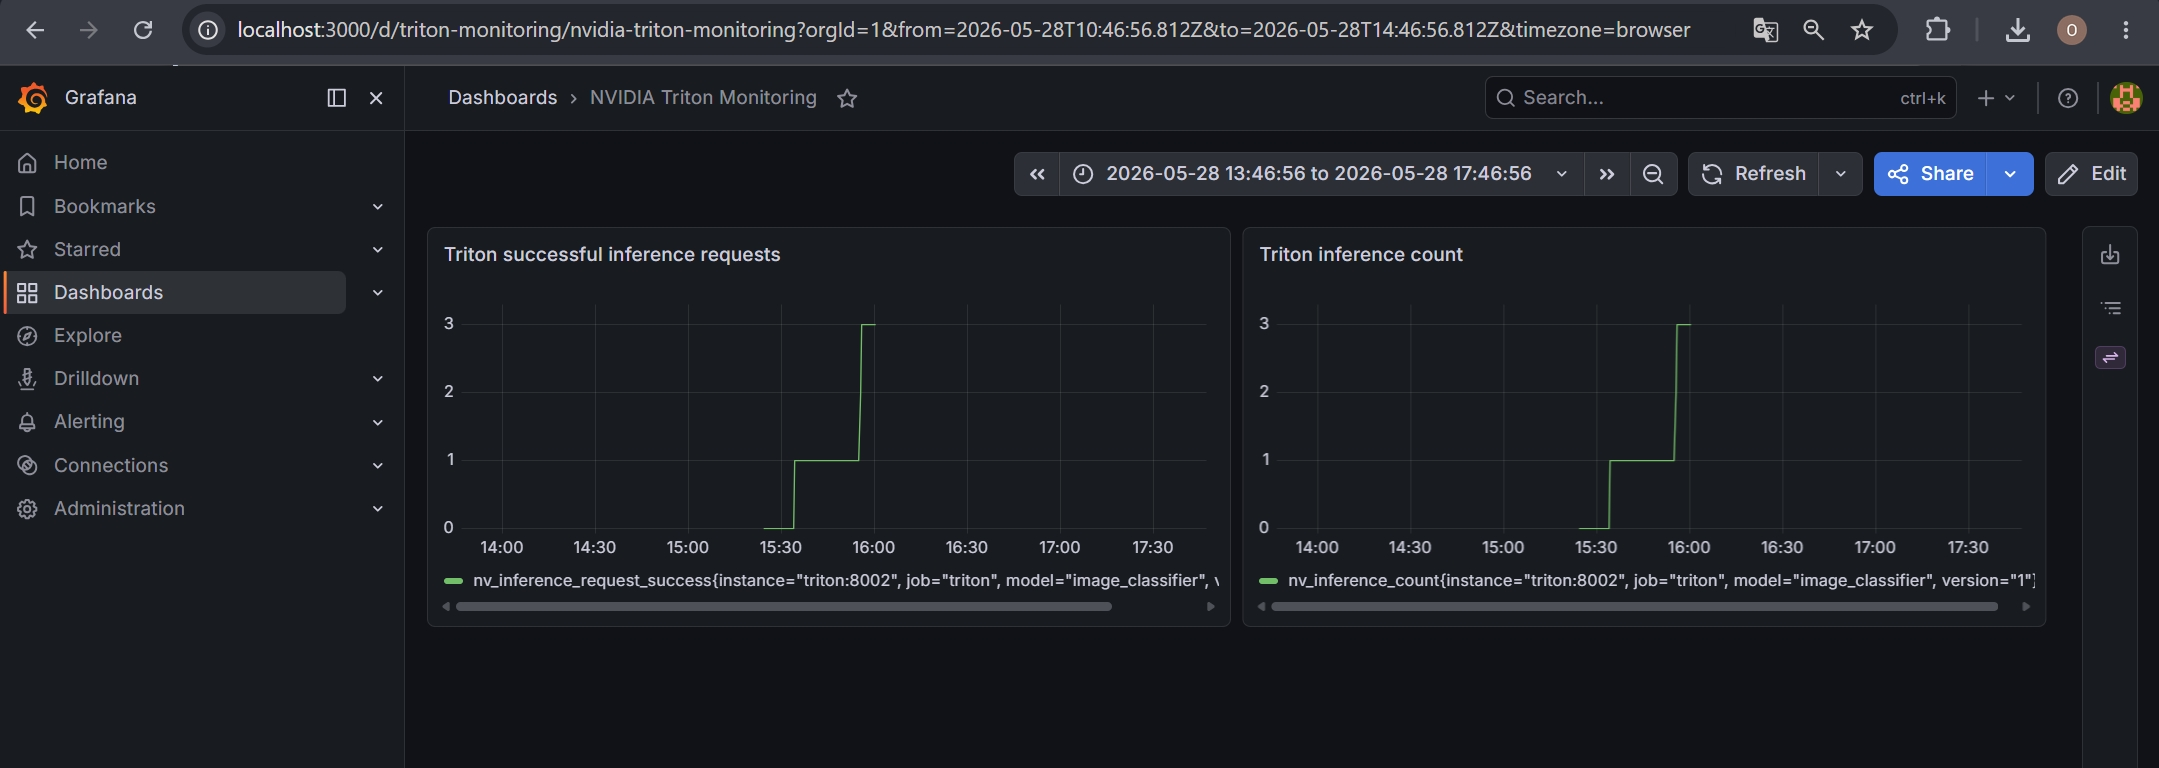


## 8. Нагрузочное тестирование

Для выполнения нескольких запросов подряд используется скрипт:

```bash
python load_test.py examples/test.jpg
```

Скрипт отправляет несколько запросов к API и выводит среднее время ответа.

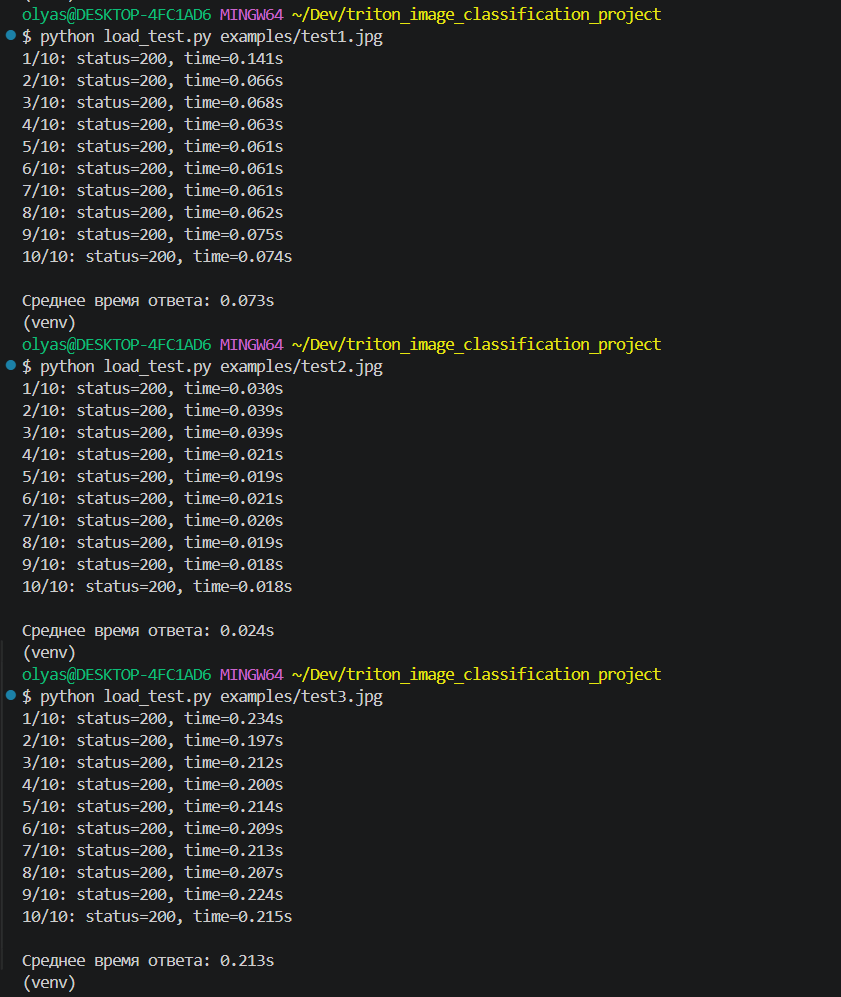


## 9. Вывод

В ходе практической работы была выполнена контейнеризация и развёртывание модели классификации изображений с использованием NVIDIA Triton Inference Server.

Были подготовлены:

- репозиторий моделей Triton;
- конфигурационный файл `config.pbtxt`;
- FastAPI-сервис для отправки изображений на инференс;
- Docker Compose-конфигурация;
- мониторинг с использованием Prometheus и Grafana.

Развёртывание модели через Triton позволяет отделить процесс инференса от прикладного API и приблизить проект к промышленному формату эксплуатации ML-моделей.
